# Week 12 Demo: Estimating Causal Effects Under Interference
## Exposure Mapping for Spillover Effects in Social Network Experiments

### By Farhan Shaikh and Elena Murray

This demo is based on the paper 'Estimating Average Causal Effects Under General Interference, with Application to a Social Network Experiment' by Aronow and Samii (2017). 

## Part 1: Social Network Data

To demonstrate the main concepts from this paper, we will be working with the same data used by Aronow and Samii in Section 10 of the paper: Analysis of a social network experiment. 

This analysis uses data from a real experiment conducted for a previous study by Paluck, Shepard and Aronow (2016). It comes from a field experiment with middle schools in the US, as part of a study on reducing peer conflict and bullying by introducing an intervention called 'Roots' that encouraged students to take a stance against conflcit at school. The data is included in this demo repo, but it is also available here: https://www.pnas.org/doi/10.1073/pnas.1514483113#data-availability 


### Step 1: Load the data and extract the relevant columns. 

In [1]:
import pandas as pd
import numpy as np
from collections import defaultdict
import random

# Set random seeds for reproducibility
np.random.seed(42)
random.seed(42)

# Load data
df = pd.read_csv(
    "Data/da37070_0001.csv",
    engine="python",
    on_bad_lines="skip"
)

# Replace ICPSR missing codes with NaN
missing_codes = [-55, -66, -77, -88, -95, -96, -97, -98, -99]
df = df.replace(missing_codes, np.nan)

# Select columns
keep_cols = [
    "ID",
    "UID",
    "SCHTREAT",
    "SCHID",
    "TREAT",
    "WRISTW2",
    "ST1","ST2","ST3","ST4","ST5",
    "ST6","ST7","ST8","ST9","ST10"
]
keep_cols = [c for c in keep_cols if c in df.columns]
df_sub = df[keep_cols].copy()


While the original data from the study has data from 56 schools with 24,1919 students, this dataset includes only a sub-set of the data, which we can check with the code below:

In [2]:
#Check the data shape

num_unique_uids = df_sub["UID"].nunique()
print("Number of unique students:", num_unique_uids)

num_unique_schools = df_sub["SCHID"].nunique()
print("Number of unique schools:", num_unique_schools)

Number of unique students: 5989
Number of unique schools: 17


While this dataset is a reduced sample of the original full dataset, the structure and network features for the schools that are included are the same. 

### Step 2: Create the Network. 

Here, we build an undirected peer network using the friendship nominations recorded in ST1–ST10. Each student has a unique identifier (UID) and a within-school roster number (ID), and they nominate up to ten friends from their using these roster numbers, based on the question "Who did you choose to spend time with in the last few weeks". 

Because nominations occur only within the same school (SCHID), we map each (school, roster ID) pair to the corresponding UID. We then create an undirected edge between two students whenever either one nominates the other. The result is a school-clustered undirected graph in which an edge between A and B means that at least one of them named the other as a friend.

In [3]:
df_sub = df_sub.copy()

# clean roster IDs
df_sub["ID"] = (
    df_sub["ID"].astype(str).str.strip()
    .replace({"--blank--": np.nan, "": np.nan})
)
df_sub["ID"] = pd.to_numeric(df_sub["ID"], errors="coerce")
df_sub = df_sub[df_sub["ID"].notna()].copy()
df_sub["ID"] = df_sub["ID"].astype(int)

# clean ST nomination columns
st_cols = [f"ST{i}" for i in range(1, 11)]
for col in st_cols:
    df_sub[col] = pd.to_numeric(df_sub[col], errors="coerce")

# mapping
roster_to_uid = {
    (row.SCHID, row.ID): row.UID
    for row in df_sub.itertuples()
}

# directed adjacency
adj_directed = defaultdict(set)

# build directed edges: UID -> nominated UID
for row in df_sub.itertuples():
    ego_uid = row.UID
    school = row.SCHID

    for col in st_cols:
        friend_roster = getattr(row, col)
        if pd.isna(friend_roster):
            continue

        friend_uid = roster_to_uid.get((school, int(friend_roster)))
        if friend_uid is None:
            continue

        # directed edge ego_uid → friend_uid
        adj_directed[ego_uid].add(friend_uid)

# convert to lists
adj_directed = {uid: sorted(list(neighs)) for uid, neighs in adj_directed.items()}

# diagnostic
num_edges = sum(len(v) for v in adj_directed.values())
print("Directed edges:", num_edges)
for uid in list(adj_directed.keys())[:5]:
    print(uid, "->", adj_directed[uid])

Directed edges: 44875
100001 -> [100002, 100012, 100013, 100022, 100028, 100032, 100077, 100140, 100178, 104999]
100002 -> [100007, 100009, 100013, 100020, 100021, 100031, 100032]
100003 -> [100001, 100014, 100020, 100021, 100024, 100031, 100045, 100072, 100203, 104999]
100004 -> [100002, 100008, 100019, 100022, 100024, 100032, 104999]
100005 -> [100002, 100004, 100010, 100021, 100032, 100045, 100258]


Above, we can see an example of how students have nominated other students who form part of their network. This is easier to see and understand as a visualisation. 

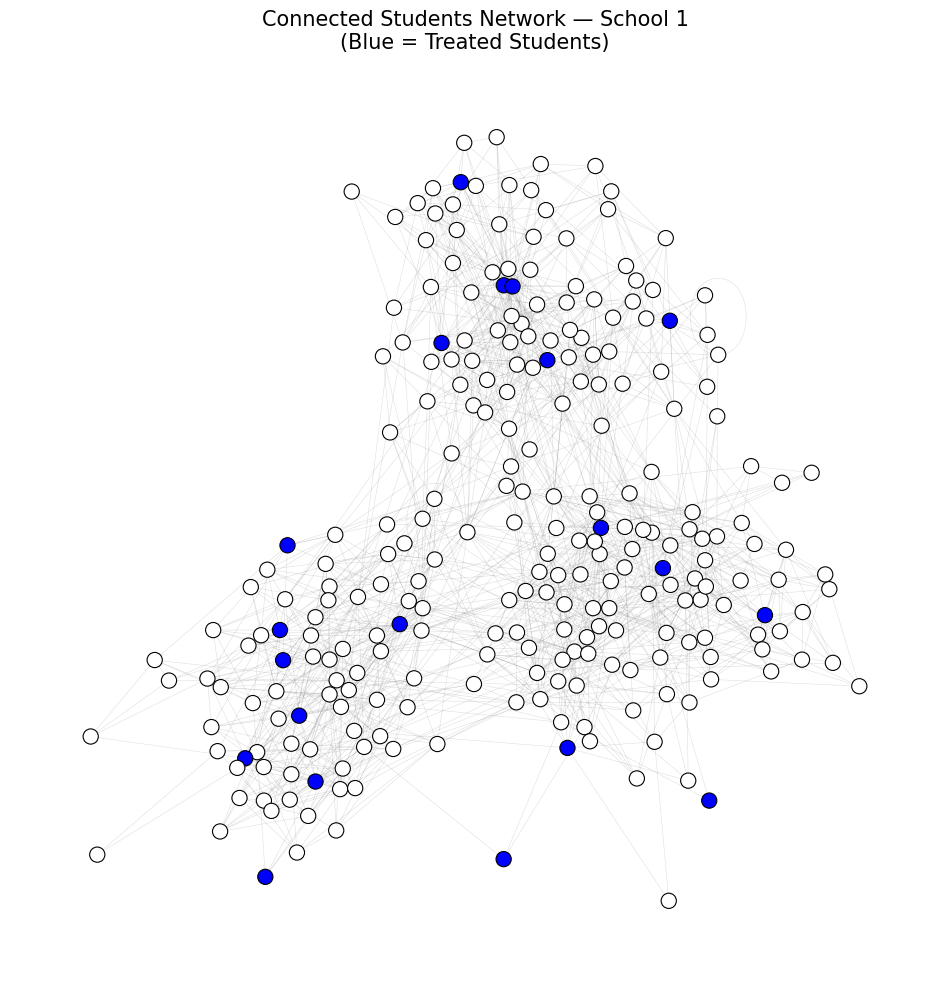

In [4]:
#Visualisation of one school's student network

import networkx as nx
import matplotlib.pyplot as plt

# Create TREAT_num
df_sub["TREAT_num"] = (
    df_sub["TREAT"]
        .astype(str)
        .str.extract(r"(\d+)")
        .astype(float)
)
df_sub["TREAT_num"] = df_sub["TREAT_num"].fillna(0).astype(int)


# Pick one school (you can change this)
one_school = df_sub["SCHID"].unique()[0]

# Get all UIDs in that school
school_uids = set(df_sub.loc[df_sub["SCHID"] == one_school, "UID"])

# Build an undirected graph for just this school
G_school = nx.Graph()
G_school.add_nodes_from(school_uids)

# Build edges (undirected)
for ego_uid in school_uids:
    if ego_uid in adj_directed:
        for friend_uid in adj_directed[ego_uid]:
            if friend_uid in school_uids:
                G_school.add_edge(ego_uid, friend_uid)

# Largest connected component
G_lcc = G_school.subgraph(
    max(nx.connected_components(G_school), key=len)
).copy()

# Determine observed treated seeds (TREAT_num == 1)
treated_uids = df_sub[df_sub["TREAT_num"] == 1]["UID"].tolist()
treated_set = set(treated_uids)

# Node colour: blue = treated, white = not treated
node_colors = [
    "blue" if uid in treated_set else "white"
    for uid in G_lcc.nodes()
]

# Draw the network
plt.figure(figsize=(12,12))
pos = nx.spring_layout(G_lcc, seed=42, k=0.20, iterations=200)

nx.draw_networkx_edges(G_lcc, pos, width=0.4, alpha=0.25, edge_color="gray")

nx.draw_networkx_nodes(
    G_lcc, pos,
    node_size=120,
    node_color=node_colors,
    edgecolors="black",
    linewidths=0.8
)

plt.title(
    f"Connected Students Network — School {one_school}\n(Blue = Treated Students)",
    fontsize=15
)
plt.axis("off")
plt.show()

## Part 2: Exposure Mapping

A key concept in Aronow and Saami's paper is the idea of exposure mapping, which relates treatments assigned to exposures received:

$$f(z, \theta_i) \;\in\; \Delta = \{d_1, d_2, \ldots, d_K\}$$

where

- $f(\cdot)$: the exposure mapping
- $\theta_i$: characteristics of unit i (e.g., its neighbors in a network)
- $\Delta$: the set of K possible exposure conditions

This analysis uses the following exposure mappings:

- d000: control school
- d001: treated school but student untreated, no treated neighbours
- d011: student untreated, ≥1 treated neighbour
- d101: student treated, no treated neighbours
- d111: student treated + ≥1 treated neighbour

We visualise the direct and indirect exposure mapping in the graph below.

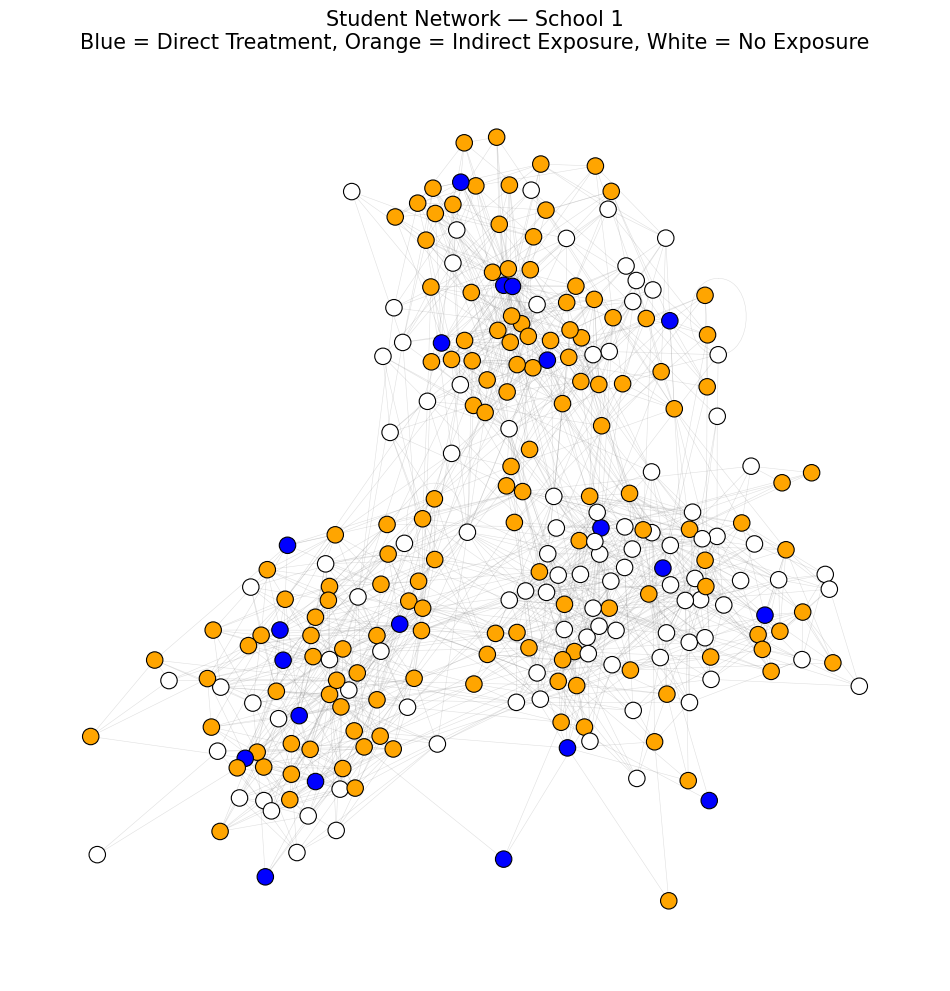

In [5]:
# Create TREAT_num
df_sub["TREAT_num"] = (
    df_sub["TREAT"]
        .astype(str)
        .str.extract(r"(\d+)")
        .astype(float)
)
df_sub["TREAT_num"] = df_sub["TREAT_num"].fillna(0).astype(int)

# ------------------------------------------------------------
# 1. Pick one school to visualize
# ------------------------------------------------------------
one_school = df_sub["SCHID"].unique()[0]
school_uids = set(df_sub.loc[df_sub["SCHID"] == one_school, "UID"])

# ------------------------------------------------------------
# 2. Build undirected graph for that school
# ------------------------------------------------------------
G_school = nx.Graph()
G_school.add_nodes_from(school_uids)

for ego_uid in school_uids:
    if ego_uid in adj_directed:
        for friend_uid in adj_directed[ego_uid]:
            if friend_uid in school_uids:
                G_school.add_edge(ego_uid, friend_uid)

# Largest connected component
G_lcc = G_school.subgraph(
    max(nx.connected_components(G_school), key=len)
).copy()

# ------------------------------------------------------------
# 3. Observed treatment vector
# ------------------------------------------------------------
Z_obs_series = (df_sub.set_index("UID")["TREAT_num"] == 1).astype(int)

# ------------------------------------------------------------
# 4. Identify INDIRECT exposure (has ≥1 treated neighbour)
# ------------------------------------------------------------
indirect_exposed = set()

for uid in G_lcc.nodes():
    neighbors = list(G_lcc.neighbors(uid))
    # If any neighbor is treated, and this student is not treated
    if Z_obs_series.loc[uid] == 0:
        if any(Z_obs_series.loc[n] == 1 for n in neighbors):
            indirect_exposed.add(uid)

# ------------------------------------------------------------
# 5. Build node color vector
# ------------------------------------------------------------
node_colors = []
for uid in G_lcc.nodes():
    if Z_obs_series.loc[uid] == 1:
        node_colors.append("blue")       # directly treated
    elif uid in indirect_exposed:
        node_colors.append("orange")     # indirect exposure
    else:
        node_colors.append("white")      # no exposure

# ------------------------------------------------------------
# 6. Draw the network
# ------------------------------------------------------------
plt.figure(figsize=(12,12))
pos = nx.spring_layout(G_lcc, seed=42, k=0.20, iterations=200)

nx.draw_networkx_edges(
    G_lcc, pos,
    width=0.4, alpha=0.25, edge_color="gray"
)

nx.draw_networkx_nodes(
    G_lcc, pos,
    node_size=140,
    node_color=node_colors,
    edgecolors="black",
    linewidths=0.8
)

plt.title(
    f"Student Network — School {one_school}\n"
    "Blue = Direct Treatment, Orange = Indirect Exposure, White = No Exposure",
    fontsize=15
)
plt.axis("off")
plt.show()

## Part 3: Calculating Causal Estimands

### Step 1: Approximate Exposure Probabilities πᵢ(dₖ)

Aronow & Samii define a generalized probability of exposure $\pi_i$ for every student $i: πᵢ(d) = Pr(Z = z)$. A unit $i$'s generalized probability of exposure $\pi_i$  tells us the probability of $i$ being subject to each of the possible exposures in $\{d_1, \ldots, d_K\}$:

$$\pi_i(d_k)
= \sum_{z \in \Omega} I\!\left(f(z, \theta_i) = d_k\right)\Pr(Z = z)
= \sum_{z \in \Omega} p_z \, I\!\left(f(z, \theta_i) = d_k\right).$$

We calculate this by using the randomization design from the experiment:

- School‐level treatment is fixed (SCHTREAT from data - half of schools were assigned treatment and half control)
- Seed-eligibility (ie. whether a student is eligible to receive treatment) is also fixed based on an algorithm that selected a group of students selected to potentially participate in the Roots (shown by TREAT ∈ {1,2} in the dataset). Designed to represent roughly 15% of the school population, blocked by gender and grade.
- Within schools, seed-eligible students are randomized with P 0.5 into treated or control
- Seed‐ineligible students are always control
- Students in control schools are always control

Therefore, to calculate the exposure probabilities, we randomise $Z$ only among the seed-eligible students in treated schools. 

We approximate these exposure probabilities using a Monte Carlo simulation, repeatedly drawing treatment assignments from the experiment’s actual randomization design and recording how often each unit falls into each exposure condition. This follows Aronow and Samii’s recommendation, since the full assignment space $\Omega$ is often too large to construct explicitly, making exact computation of exposure probabilities infeasible.

In [ ]:
import numpy as np
import pandas as pd


def simulate_exposure_probabilities(
    df_sub,
    adj_directed,
    R=5000,
    levels=None,
    seed=123
):
    """
    Estimate exposure probabilities π_i(d) via simulation under
    the ROOTS randomization design used in Aronow & Samii.

    Parameters
    ----------
    df_sub : pandas DataFrame
        Must contain columns: UID, SCHID, TREAT, SCHTREAT.
    adj_directed : dict
        Directed adjacency list: uid -> list of nominated friends.
    R : int
        Number of simulation replications.
    levels : list or None
        Ordered list of exposure categories.
        Default: ["d000", "d001", "d011", "d101", "d111"]
    seed : int
        Random seed for reproducibility.

    Returns
    -------
    pi_df : DataFrame
        π_i(d) for all UIDs and exposure categories.
    objects : dict
        Contains useful intermediate objects:
        (uids, uid_to_idx, adj_undir, school_of, S_school_fixed, elig)
    """

    np.random.seed(seed)

    # ---------------------------
    # 1. BASIC INDEX SETUP
    # ---------------------------
    uids = sorted(df_sub["UID"].unique())
    N = len(uids)
    uid_to_idx = {u: i for i, u in enumerate(uids)}

    # ---------------------------
    # 2. BUILD UNDIRECTED ADJACENCY
    # ---------------------------
    adj_undir = [[] for _ in range(N)]
    for ego_uid, neighs in adj_directed.items():
        if ego_uid not in uid_to_idx:
            continue
        i = uid_to_idx[ego_uid]

        for friend_uid in neighs:
            if friend_uid not in uid_to_idx:
                continue
            j = uid_to_idx[friend_uid]

            adj_undir[i].append(j)
            adj_undir[j].append(i)  # undirected

    # ---------------------------
    # 3. SCHOOL INDEXING
    # ---------------------------
    school_ids = np.sort(df_sub["SCHID"].unique())
    school_to_idx = {s: j for j, s in enumerate(school_ids)}

    school_of = np.array([
        school_to_idx[df_sub.loc[df_sub["UID"] == u, "SCHID"].iloc[0]]
        for u in uids
    ])

    J = len(school_ids)

    # ---------------------------
    # 4. SCHOOL TREATMENT (FIXED)
    # ---------------------------
    df_sub["SCHTREAT_num"] = (
        df_sub["SCHTREAT"]
            .astype(str)
            .str.extract(r"(\d)")
            .astype(float)
            .fillna(0)
            .astype(int)
    )

    S_school_fixed = (
        df_sub.groupby("SCHID")["SCHTREAT_num"]
        .first()
        .loc[school_ids]
        .values
    )

    # ---------------------------
    # 5. SEED ELIGIBILITY
    # ---------------------------
    df_sub["TREAT_num"] = (
        df_sub["TREAT"]
        .astype(str)
        .str.extract(r"(\d+)")
        .astype(float)
        .fillna(0)
        .astype(int)
    )

    elig = df_sub.set_index("UID").loc[uids, "TREAT_num"].isin([1, 2]).values

    # ---------------------------
    # 6. EXPOSURE MAPPING FUNCTION
    # ---------------------------
    if levels is None:
        levels = ["d000", "d001", "d011", "d101", "d111"]

    level_to_idx = {d: k for k, d in enumerate(levels)}

    def exposure_5cat(Z):
        """Compute exposure category for all units."""
        D = np.empty(N, dtype=object)
        S = S_school_fixed[school_of]

        neigh_tr = np.array([Z[adj_undir[i]].sum() if adj_undir[i] else 0
                             for i in range(N)])

        for i in range(N):
            si = S[i]
            zi = Z[i]
            nt = neigh_tr[i]

            if si == 0:
                D[i] = "d000"
            elif zi == 1 and nt > 0:
                D[i] = "d111"
            elif zi == 1 and nt == 0:
                D[i] = "d101"
            elif zi == 0 and nt > 0:
                D[i] = "d011"
            else:
                D[i] = "d001"

        return D

    # ---------------------------
    # 7. RANDOMIZATION
    # ---------------------------
    def randomize_once():
        """ROOTS randomization: half of eligible students in treated schools."""
        Z = np.zeros(N, dtype=int)
        for j in range(J):
            idxs = np.where(school_of == j)[0]
            if S_school_fixed[j] == 1:
                elig_idxs = idxs[elig[idxs]]
                m = len(elig_idxs)
                treat_size = m // 2
                if treat_size > 0:
                    chosen = np.random.choice(
                        elig_idxs, treat_size, replace=False
                    )
                    Z[chosen] = 1
        return Z

    # ---------------------------
    # 8. SIMULATION
    # ---------------------------
    D_sims_idx = np.zeros((R, N), dtype=int)

    for r in range(R):
        Z = randomize_once()
        D = exposure_5cat(Z)

        try:
            D_sims_idx[r] = [level_to_idx[d] for d in D]
        except KeyError as e:
            raise ValueError(f"Exposure level missing or incorrect: {e}")

    counts = np.zeros((N, len(levels)), dtype=int)
    for r in range(R):
        counts[np.arange(N), D_sims_idx[r]] += 1

    pi_hat = counts / R
    pi_df = pd.DataFrame(pi_hat, index=uids, columns=levels)

    # ---------------------------
    # OUTPUT
    # ---------------------------
    objects = dict(
        uids=uids,
        uid_to_idx=uid_to_idx,
        adj_undir=adj_undir,
        school_of=school_of,
        S_school_fixed=S_school_fixed,
        levels=levels
    )

    return pi_df, objects


Seed eligible students: 824 out of 5985
        d000    d001    d011    d101    d111
100001   0.0  0.2419  0.7581  0.0000  0.0000
100002   0.0  0.2419  0.2568  0.2552  0.2461
100003   0.0  0.2493  0.7507  0.0000  0.0000
100004   0.0  0.1114  0.8886  0.0000  0.0000
100005   0.0  0.4987  0.5013  0.0000  0.0000
Row sums: count    5.985000e+03
mean     1.000000e+00
std      5.370052e-18
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
dtype: float64
All rows sum to 1: True


Here, we create a comparison table to see how these estimates appear for four students in different conditions:

In [7]:
# Display the results to compare for selected students

# INPUT: choose 4 UIDs (must exist in pi_df.index)
uids_to_check = [1100009, 600305, 100002, 1200194]   #can change these

# Validate
for u in uids_to_check:
    if u not in pi_df.index:
        raise ValueError(f"UID {u} not found in the dataset.")


# BUILD COMPARISON TABLE
rows = []

for uid in uids_to_check:
    i = uid_to_idx[uid]                 # internal index 0..N-1
    sch = df_sub.loc[df_sub["UID"] == uid, "SCHID"].iloc[0]
    school_idx = school_to_idx[sch]
    
    school_treat = S_school_fixed[school_idx]        # 0/1
    eligible = bool(elig[i])                         # True/False

    # Raw label from the dataset (unchanged)
    raw_treat_label = df_sub.loc[df_sub["UID"] == uid, "TREAT"].iloc[0]

    # Approx empirical P(Z_i = 1)
    P_Z1 = (
        (D_sims_idx[:, i] == level_to_idx["d101"]).sum()
        + (D_sims_idx[:, i] == level_to_idx["d111"]).sum()
    ) / R
    
    # Degree in undirected adjacency: outgoing + incoming unique set
    neighbors = set(adj_directed.get(uid, [])) | {uids[j] for j in adj_in[i]}
    degree = len(neighbors)
    
    # Exposure probabilities
    pi_vals = pi_df.loc[uid]

    rows.append({
        "UID": uid,
        "SCHID": sch,
        "School_Treated": school_treat,
        "Treatment": raw_treat_label,          
        "Eligible": eligible,
        "Number of peer connections": degree,
        "π(d000)": round(pi_vals["d000"], 3),
        "π(d001)": round(pi_vals["d001"], 3),
        "π(d011)": round(pi_vals["d011"], 3),
        "π(d101)": round(pi_vals["d101"], 3),
        "π(d111)": round(pi_vals["d111"], 3),
    })

comparison_df = pd.DataFrame(rows)


# OUTPUT TABLE
print("\nStudent Comparison Table:")
display(comparison_df)


Student Comparison Table:


,UID,SCHID,School_Treated,Treatment,Eligible,Number of peer connections,π(d000),π(d001),π(d011),π(d101),π(d111)
0,1100009,11,0,(0) Not treatment or control,False,8,1.0,0.000,0.000,0.000,0.000
1,600305,6,1,(1) Treatment,True,16,0.0,0.116,0.380,0.131,0.373
2,100002,1,1,(2) Control,True,14,0.0,0.242,0.257,0.255,0.246
3,1200194,12,0,(1) Treatment,True,11,1.0,0.000,0.000,0.000,0.000


### Step 2: Calculate HT Estimator

Next, we compute the Horvitz–Thompson estimator, which uses inverse probability weighting based on the exposure probabilities to obtain unbiased estimates of the average potential outcome under each exposure condition.

As per the paper, only students selected as “seed-eligible” have a non-zero possibility of being in all four exposure conditions. Thus, we limit the present analysis to the set of students who are labelled as seed-eligible. 

The outcome variable is defined as whether students are wearing a Roots wristband after the intervention takes place (binary). 

In [8]:
#Calculate Horvitz–Thompson estimators μ_HT(d) for seed-eligible students

# 1. DEFINE SEED-ELIGIBLE POPULATION
#    Seed-eligible = TREAT ∈ {1, 2} (Roots design)

# Ensure numeric TREAT codes already extracted
df_sub["TREAT_num"] = (
    df_sub["TREAT"]
        .astype(str)
        .str.extract(r"(\d+)")
        .astype(float)
)

elig_series = df_sub.set_index("UID")["TREAT_num"].isin([1, 2])


# 2. OUTCOME: WRISTW2 → numeric 0/1
df_sub["WRISTW2_num"] = (
    df_sub["WRISTW2"]
        .astype(str)
        .str.extract(r"(\d)")
        .astype(float)
)

Y_all = df_sub.set_index("UID")["WRISTW2_num"]


# 3. ANALYSIS SAMPLE:
#    - seed-eligible
#    - non-missing outcome

mask_eligible = elig_series
mask_outcome  = Y_all.notna()

analysis_mask = mask_eligible & mask_outcome
analysis_uids = pi_df.index.intersection(elig_series.index[analysis_mask])

print("Number of seed-eligible students in analysis:", len(analysis_uids))

# Restrict outcome and π̂ to analysis sample
Y   = Y_all.loc[analysis_uids]
pi_a = pi_df.loc[analysis_uids]    # columns = levels

# Observed Z (individual treatment) from the real data:
#  TREAT_num == 1 means the student was assigned to receive the Roots program.
Z_obs = (df_sub.set_index("UID").loc[uids, "TREAT_num"] == 1).astype(int).values

# Compute observed exposure category using the same exposure mapping
D_obs = exposure_5cat(Z_obs, S_school_fixed)

# 4. OBSERVED EXPOSURES FOR EACH UID
#    D_obs must already be computed from the real experiment:
#    D_obs = exposure_5cat(Z_obs, S_school_fixed)
#    and aligned with `uids` (the full UID list)

D_obs_by_uid = pd.Series(D_obs, index=uids)

# Indicator matrix I_obs(uid, d)
levels = ["d000", "d001", "d011", "d101", "d111"]
I_obs = pd.DataFrame(0, index=analysis_uids, columns=levels)

for uid in analysis_uids:
    d = D_obs_by_uid[uid]
    I_obs.loc[uid, d] = 1


# 5. HORVITZ–THOMPSON EXPOSURE-SPECIFIC MEANS μ_HT(d)
#    For seed-eligible students only
HT_mu = {}

for d in levels:
    # Only include units with π_i(d) > 0 to avoid division by zero
    mask_d = (pi_a[d] > 0)
    
    numer = I_obs.loc[mask_d, d] * (Y.loc[mask_d] / pi_a.loc[mask_d, d])
    HT_mu[d] = numer.mean()

print("\n=========== HT Exposure-Specific Means μ_HT(d) (seed-eligible) ===========")

for d in levels:
    print(f"{d}: {HT_mu[d]:.4f}")

print("\n=========== Interpretation of μ_HT(d) ===========")

interpret_text = {
    "d101": "Estimated probability of wearing a wristband if a student had DIRECT exposure only.",
    "d011": "Estimated probability of wearing a wristband if the student had INDIRECT exposure only.",
    "d001": "Estimated wristband rate if the school received treatment but the student had no treated peers and was not treated.",
    "d000": "Estimated wristband rate if the student had NO EXPOSURE at all (control school + no treated peers).",
    "d111": "Estimated wristband rate if the student had BOTH direct and indirect exposure.",
}

for d in levels:
    print(f"\nμ_HT({d}) = {HT_mu[d]:.4f}")
    print("→ " + interpret_text[d])


Number of seed-eligible students in analysis: 637

=========== HT Exposure-Specific Means μ_HT(d) (seed-eligible) ===========
d000: 0.0251
d001: 0.4658
d011: 0.4851
d101: 0.7348
d111: 0.5946

=========== Interpretation of μ_HT(d) ===========

μ_HT(d000) = 0.0251
→ Estimated wristband rate if the student had NO EXPOSURE at all (control school + no treated peers).

μ_HT(d001) = 0.4658
→ Estimated wristband rate if the school received treatment but the student had no treated peers and was not treated.

μ_HT(d011) = 0.4851
→ Estimated probability of wearing a wristband if the student had INDIRECT exposure only.

μ_HT(d101) = 0.7348
→ Estimated probability of wearing a wristband if a student had DIRECT exposure only.

μ_HT(d111) = 0.5946
→ Estimated wristband rate if the student had BOTH direct and indirect exposure.


These numbers represent the estimated average potential outcome under each exposure mapping. 

One question arises: why do we not see μ_HT(d000) = 0? This is what we would expect. 

In [9]:
#Check for students in control schools who wore a wristband
count_control_yes = (
    (df_sub["SCHTREAT_num"] == 0) &
    (df_sub["WRISTW2_num"] == 1)
).sum()

print("Number of students in control schools who wore a wristband:", count_control_yes)

Number of students in control schools who wore a wristband: 90


We can observe that some students still report wearing a wristband despite being in a control school and having 0 exposure to the program, which explains this result.

### Step 3: Calculate the Causal Effects:

In [10]:
#HT CAUSAL EFFECTS τ_HT(d, d000) FOR SEED-ELIGIBLE STUDENTS
baseline = "d000"
HT_tau = {
    (d, baseline): HT_mu[d] - HT_mu[baseline]
    for d in levels if d != baseline
}

print("\n=========== HT Causal Effects τ_HT(d, d000) (seed-eligible) ===========")
for (d, base), val in HT_tau.items():
    print(f"tau_HT({d}, {base}) = {val:.4f}")


=========== HT Causal Effects τ_HT(d, d000) (seed-eligible) ===========
tau_HT(d001, d000) = 0.4406
tau_HT(d011, d000) = 0.4600
tau_HT(d101, d000) = 0.7096
tau_HT(d111, d000) = 0.5695


These values represent the estimated increase in the probability of wearing a wristband for seed-eligible students under each exposure condition compared to having no exposure (d000), using the Horvitz-Thompson inverse-probability-weighted estimator.

Next, we compute the Hajek estimator. This normalizes the HT weights so they sum to 1, giving lower variance. 

$\hat{\mu}_{\text{H}}^{\,(\text{eligible})}(d)$ =
$\frac{
    \displaystyle \sum_{i \in \mathcal{E}} 
        \frac{\mathbb{I}\{D_i = d\} \, Y_i}
             {\hat{\pi}_i(d)}
}{
    \displaystyle \sum_{i \in \mathcal{E}} 
        \frac{\mathbb{I}\{D_i = d\}}
             {\hat{\pi}_i(d)}
}$


In [12]:
Hajek_mu = {}

for d in levels:
    mask_d = (pi_a[d] > 0)
    
    w = I_obs.loc[mask_d, d] / pi_a.loc[mask_d, d]
    y_w = I_obs.loc[mask_d, d] * (Y.loc[mask_d] / pi_a.loc[mask_d, d])
    
    Hajek_mu[d] = y_w.sum() / w.sum()

print("\n=== Hájek Estimator μ_H(d) ===")
for d in levels:
    print(f"{d}: {Hajek_mu[d]:.4f}")



=== Hájek Estimator μ_H(d) ===
d000: 0.0251
d001: 0.5072
d011: 0.4427
d101: 0.6339
d111: 0.7161


In [14]:
baseline = "d000"
HJ_tau = {
    (d, baseline): Hajek_mu[d] - Hajek_mu[baseline]
    for d in levels if d != baseline
}

print("\n=========== Hajek Causal Effects τ_HJ(d, d000) ===========")
for (d, base), val in HJ_tau.items():
    print(f"tau_HJ({d}, {base}) = {val:.4f}")


=========== Hajek Causal Effects τ_HJ(d, d000) ===========
tau_HJ(d001, d000) = 0.4821
tau_HJ(d011, d000) = 0.4175
tau_HJ(d101, d000) = 0.6088
tau_HJ(d111, d000) = 0.6910


In [15]:
# ============================
# WLS EXPOSURE-SPECIFIC MEANS
# ============================

WLS_mu = {}

for d in levels:
    # Only use units with nonzero π_i(d)
    mask_d = (pi_a[d] > 0)

    # Numerator and denominator
    numer = (I_obs.loc[mask_d, d] * (Y.loc[mask_d] / pi_a.loc[mask_d, d])).sum()
    denom = (I_obs.loc[mask_d, d] * (1 / pi_a.loc[mask_d, d])).sum()

    WLS_mu[d] = numer / denom

print("\n=========== WLS Exposure-Specific Means μ_WLS(d) ===========")
for d in levels:
    print(f"{d}: {WLS_mu[d]:.4f}")



=========== WLS Exposure-Specific Means μ_WLS(d) ===========
d000: 0.0251
d001: 0.5072
d011: 0.4427
d101: 0.6339
d111: 0.7161


In [16]:
baseline = "d000"

WLS_tau = {
    (d, baseline): WLS_mu[d] - WLS_mu[baseline]
    for d in levels if d != baseline
}

print("\n=========== WLS Causal Effects τ_WLS(d, d000) ===========")
for (d, base), val in WLS_tau.items():
    print(f"tau_WLS({d}, {base}) = {val:.4f}")



=========== WLS Causal Effects τ_WLS(d, d000) ===========
tau_WLS(d001, d000) = 0.4821
tau_WLS(d011, d000) = 0.4175
tau_WLS(d101, d000) = 0.6088
tau_WLS(d111, d000) = 0.6910


In [18]:
import pandas as pd

effect_rows = []

for d in levels:
    if d == "d000":
        continue
    row = {
        "Estimand": f"τ({d}, d000)",
        "HT": HT_tau[(d, "d000")],
        "Hajek": HJ_tau[(d, "d000")],
        "WLS": WLS_tau[(d, "d000")]
    }
    effect_rows.append(row)

effects_table = pd.DataFrame(effect_rows)
print("\n=========== Consolidated Causal Effects Table ===========")
print(effects_table)



=========== Consolidated Causal Effects Table ===========
        Estimand        HT     Hajek       WLS
0  τ(d001, d000)  0.440650  0.482051  0.482051
1  τ(d011, d000)  0.459959  0.417546  0.417546
2  τ(d101, d000)  0.709631  0.608776  0.608776
3  τ(d111, d000)  0.569457  0.691008  0.691008


## Part 4: Playground

In [13]:
#Add here